In [1]:
# Imports 
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision
import mediapipe as mp
from mediapipe.tasks import python
import matplotlib.pyplot as plt
import pandas as pd 
import pickle as pkl
from tqdm import tqdm
import os 
from PIL import Image
import cv2
import csv
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F

 


In [2]:
PATH = "C:/Users/leahz/Documents/ATC/pose-project/data"
input = f"{PATH}/099920730.jpg"

In [3]:
features = {
    "head" : [(8,7), (10,9), (8,10), (7,9)],
    "torso" : [(12,11), (24,23), (12,24), (11,23)],
    "left-leg": [(24,26), (26,28)],
    "right-leg": [(23,25), (25,27)],
    "legs":[(24,23), (26,25), (28,27), (30,32), (29,31)],
    "left-arm": [(12,14), (14,16)], 
    "right-arm": [(11,13), (13,15)],
    "full-body":[(0,24), (0,23), (0,12), (0,11)]
}

In [4]:
def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

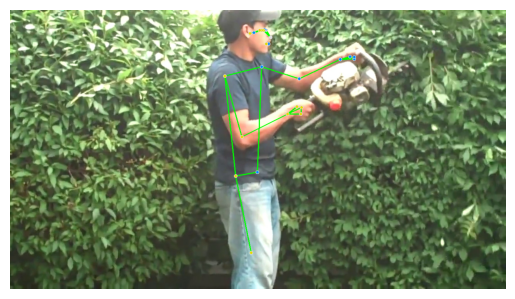

In [5]:
# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path=f'{PATH}/pose_landmarker_full.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)


# STEP 3: Load the input image.
# image = mp.Image.create_from_file(f"{PATH}/mpii_human_pose_v1/images/000004812.jpg")
image = mp.Image.create_from_file(f"{PATH}/mpii_human_pose_v1/images/099920730.jpg")


# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)


# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)


plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [6]:
detection_result

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5251737833023071, y=0.0974571704864502, z=-0.048505671322345734, visibility=0.9997201561927795, presence=0.9994076490402222, name=None), NormalizedLandmark(x=0.5156807899475098, y=0.07189589738845825, z=-0.022527512162923813, visibility=0.9995816349983215, presence=0.9990813732147217, name=None), NormalizedLandmark(x=0.5145330429077148, y=0.07129353284835815, z=-0.02260817214846611, visibility=0.9994851350784302, presence=0.9991005659103394, name=None), NormalizedLandmark(x=0.5127873420715332, y=0.0707206130027771, z=-0.02263367734849453, visibility=0.9995818734169006, presence=0.999021053314209, name=None), NormalizedLandmark(x=0.5112477540969849, y=0.07296949625015259, z=-0.06786629557609558, visibility=0.9996775388717651, presence=0.9990984201431274, name=None), NormalizedLandmark(x=0.5075831413269043, y=0.07320600748062134, z=-0.06791456043720245, visibility=0.9996541738510132, presence=0.9989933371543884, name=None), Nor

# Skeleton Sketch

In [7]:
import numpy as np
import cv2

class Skeleton:
    def __init__(self, joints, edges, joint_meta=None, edge_meta=None):
        self.joints = joints.astype(float)              
        self.edges = edges.astype(int)                  

        self.joint_meta = joint_meta if joint_meta else [{} for _ in range(len(joints))]
        self.edge_meta = edge_meta if edge_meta else [{} for _ in range(len(edges))]

    def jitter_joints(self, sigma=0.01):
        noise = np.random.normal(0, sigma, self.joints.shape)
        self.joints += noise

    def _scale_line(self, p1, p2, scale):
        p1, p2 = np.array(p1), np.array(p2)
        mid = (p1 + p2) / 2.0
        vec = p2 - p1
        new_p1 = mid - (vec * scale) / 2.0
        new_p2 = mid + (vec * scale) / 2.0
        return tuple(new_p1.astype(int)), tuple(new_p2.astype(int))

    def _get_bezier_curve(self, p1, p2, bend_factor=0.3, num_points=15):
        """Generates points for a quadratic Bezier curve."""
        p1, p2 = np.array(p1), np.array(p2)
        mid = (p1 + p2) / 2.0
        perp = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])
        control = mid + perp * bend_factor
        t = np.linspace(0, 1, num_points)[:, np.newaxis]
        curve = (1 - t)**2 * p1 + 2 * (1 - t) * t * control + t**2 * p2
        return curve.astype(np.int32)

    def _get_line_segments(self, p1, p2, num_segments=10):
        """Chops a straight line into points to allow for varying thickness."""
        x_vals = np.linspace(p1[0], p2[0], num_segments)
        y_vals = np.linspace(p1[1], p2[1], num_segments)
        return np.vstack((x_vals, y_vals)).T.astype(np.int32)

    def render(self, size=256, noise_level=3):
        canvas = np.zeros((size, size, 4), dtype=np.uint8)
        
        # --- Z-AXIS NORMALIZATION FOR OPACITY ---
        z_vals = self.joints[:, 2]
        z_min, z_max = np.min(z_vals), np.max(z_vals)
        z_range = (z_max - z_min) if (z_max - z_min) > 0 else 1.0
        
        def get_alpha(z_value):
            normalized_z = 1.0 - ((z_value - z_min) / z_range)
            return int(normalized_z * 205 + 50)
        
        # --- HEAD ELLIPSE LOGIC ---
        p7 = self.joints[7][:2] * size
        p8 = self.joints[8][:2] * size
        p4 = self.joints[4][:2] * size
        p1 = self.joints[1][:2] * size
        p0 = self.joints[0][:2] * size 

        r1 = int(np.linalg.norm(p8 - p7) / 2)
        mid_4_1 = (p4 + p1) / 2.0
        r2 = int(2 * np.linalg.norm(mid_4_1 - p0))
        
        head_alpha = get_alpha(self.joints[0, 2])
        cv2.ellipse(canvas, center=tuple(p0.astype(int)), axes=(r1, r2), 
                    angle=0, startAngle=0, endAngle=360, color=(0, 0, 0, head_alpha), thickness=2)

        # --- DRAW EDGES ---
        for (i, (a, b)) in enumerate(self.edges):
            meta = self.edge_meta[i]
            if not meta.get("visible", True) or meta.get("category") == "head":
                continue 

            p1 = tuple((self.joints[a, :2] * size).astype(int))
            p2 = tuple((self.joints[b, :2] * size).astype(int))

            scale = meta.get("length_scale", 1.0)
            if scale != 1.0:
                p1, p2 = self._scale_line(p1, p2, scale)

            avg_z = (self.joints[a, 2] + self.joints[b, 2]) / 2.0
            alpha = get_alpha(avg_z)
            color = (0, 0, 0, alpha) 
            
            base_thickness = meta.get("thickness", 2)
            strokes = meta.get("sketch_strokes", 1)

            for stroke in range(strokes):
                # Apply random overall jitter to this specific stroke
                sp1 = (p1[0] + np.random.randint(-noise_level, noise_level + 1), 
                       p1[1] + np.random.randint(-noise_level, noise_level + 1))
                sp2 = (p2[0] + np.random.randint(-noise_level, noise_level + 1), 
                       p2[1] + np.random.randint(-noise_level, noise_level + 1))

                # Get points for segments (either curve or straight line)
                if meta.get("style") == "curve":
                    jittered_bend = meta.get("bend", 0.3) + np.random.uniform(-0.05, 0.05)
                    pts = self._get_bezier_curve(sp1, sp2, bend_factor=jittered_bend)
                else:
                    # Determine segments based on line length so long lines have more variance points
                    length = np.linalg.norm(np.array(sp1) - np.array(sp2))
                    num_segments = max(4, int(length // 15)) 
                    pts = self._get_line_segments(sp1, sp2, num_segments)

                # Draw the line segment by segment, varying the thickness at each step
                for pt_idx in range(len(pts) - 1):
                    seg_p1 = tuple(pts[pt_idx])
                    seg_p2 = tuple(pts[pt_idx + 1])
                    
                    # VARYING WIDTH: Waver around the base thickness (+/- 1 pixel)
                    current_thickness = max(1, base_thickness + np.random.randint(-1, 2))
                    
                    cv2.line(canvas, seg_p1, seg_p2, color=color, thickness=current_thickness)

        # --- DRAW JOINTS ---
        for i, joint in enumerate(self.joints):
            meta = self.joint_meta[i]
            if not meta.get("visible", True):
                continue

            center = tuple((joint[:2] * size).astype(int))
            alpha = get_alpha(joint[2])
            color = (0, 0, 0, alpha)

            cv2.circle(canvas, center, radius=2, color=color, thickness=-1)
            
            if meta.get("draw_outer_ring"):
                ring_r = meta.get("ring_radius", 6)
                ring_center = (center[0] + np.random.randint(-2, 3), center[1] + np.random.randint(-2, 3))
                # Even the circles can have a tiny thickness variation
                cv2.circle(canvas, ring_center, radius=ring_r, color=color, 
                           thickness=max(1, np.random.randint(1, 3)))

        return canvas

In [8]:
# joints is all the landmarks 
# edges are the tuples of indices into the joints array that define the skeleton structure that I choose
edges = [
    # head 
    (8,6),(6,5),(5,4),(4,0),(0,1),(1,2),(2,3),(3,7),(10,9),
    # torso
    (12,11), (24,23), (12,24), (11,23),
    # left-leg
    (24,26), (26,28),
    # right-leg
    (23,25), (25,27),
    # left-arm
    (12,14), (14,16),
    # right-arm
    (11,13), (13,15),
    # left foot
    (28,30), (30,32), (32,28),
    # right foot
    (27,29), (29,31), (31,27),
    # left hand
    (16,18), (18,20), (20,16), (16,22),
    # right hand
    (15,17), (17,19), (19,15), (15,21)
]

JOINT_CATEGORIES = {
    "head": [0,1,2,3,4,5,6,7,8,9,10],
    "torso": [11,12,23,24],
    "left_arm": [11,13,15],
    "right_arm": [12,14,16],
    "left_leg": [23,25,27],
    "right_leg": [24,26,28],
    "left_hand": [15,17,18,19,20,22],
    "right_hand": [16,18,19,20,21],
    "left_foot": [28,30,32],
    "right_foot": [27,29,31]
}




In [9]:
def stylize_as_sketch(skeleton):
    # 1. Add circles to specific joints
    target_joints = [11, 12, 13, 14, 25, 26]
    for idx in target_joints:
        skeleton.joint_meta[idx]["draw_outer_ring"] = True
        skeleton.joint_meta[idx]["ring_radius"] = np.random.randint(2, 8) # Varying sizes

    # 2. Torso Logic: Bulge thinner rectangles
    # Measure shoulder width (11 to 12) vs torso height (11 to 23)
    p11, p12, p23 = skeleton.joints[11], skeleton.joints[12], skeleton.joints[23]
    width = np.linalg.norm(p12 - p11)
    height = np.linalg.norm(p23 - p11)
    
    # Find the edges corresponding to the torso sides and curve them if thin
    if width / (height + 1e-5) < 0.6: # If thin
        for i, (a, b) in enumerate(skeleton.edges):
            if (a, b) in [(12, 24), (11, 23), (24, 12), (23, 11)]: # Left and right sides
                skeleton.edge_meta[i]["style"] = "curve"
                # Bend left side left, right side right
                skeleton.edge_meta[i]["bend"] = 0.3 if a in [12, 24] else -0.3 

    # 3. Arms/Legs: Sketchy, overlapping lines & Length variation
    sketch_categories = ["left_arm", "right_arm", "left_leg", "right_leg"]
    for i, (a, b) in enumerate(skeleton.edges):
        cat_a = skeleton.joint_meta[a].get("category")
        cat_b = skeleton.joint_meta[b].get("category")
        
        if cat_a in sketch_categories or cat_b in sketch_categories:
            # Tell the renderer to draw 3 jittery lines instead of 1
            skeleton.edge_meta[i]["sketch_strokes"] = 3
            
            # Randomly make the line 10% shorter (0.9) to 20% longer (1.2)
            skeleton.edge_meta[i]["length_scale"] = np.random.uniform(0.9, 1.2)
            
    return skeleton

In [10]:
def construct_skeleton_from_mediapipe_result(
    detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.15,
):
    """
    Constructs a Skeleton from a MediaPipe detection result.

    Args:
        detection_result: MediaPipe pose detection result.
        edges: list of (start, end) tuples defining the skeleton connectivity.
        normalize_to_bbox: if True, re-center and scale landmarks to fit [0, 1]
            based on the detected pose box.
        bbox_padding: relative padding added around the pose bbox.

    Returns:
        Skeleton instance with joints, edges, joint_meta, and edge_meta.
    """
    if not detection_result.pose_landmarks:
        raise ValueError("No pose landmarks found in detection_result.")

    landmarks = detection_result.pose_landmarks[0]

    joints = []
    joint_meta = []

    for i, landmark in enumerate(landmarks):
        x, y, z = landmark.x, landmark.y, landmark.z

        category = None
        for cat, indices in JOINT_CATEGORIES.items():
            if i in indices:
                category = cat
                break

        joints.append([x, y, z])
        joint_meta.append({
            "category": category,
            "visibility": landmark.visibility,
        })

    joints = np.array(joints, dtype=float)

    if normalize_to_bbox:
        visible = np.array([m["visibility"] >= 0.5 for m in joint_meta], dtype=bool)
        visible_xy = joints[visible, :2] if visible.any() else joints[:, :2]

        min_xy = visible_xy.min(axis=0)
        max_xy = visible_xy.max(axis=0)
        center = (min_xy + max_xy) / 2.0
        size = (max_xy - min_xy).max() * (1.0 + 2.0 * bbox_padding)
        size = max(size, 1e-6)

        joints[:, :2] = ((joints[:, :2] - center) / size) + 0.5

    edge_meta = []
    for (a, b) in edges:
        visible = True
        if joint_meta[a]["visibility"] < 0.5 or joint_meta[b]["visibility"] < 0.5:
            visible = False
        edge_meta.append({
            "start": a,
            "end": b,
            "visible": visible,
            "thickness": 2,
            "type": None,
        })

    return Skeleton(
        joints=joints,
        edges=np.array(edges, dtype=int),
        joint_meta=joint_meta,
        edge_meta=edge_meta,
    )

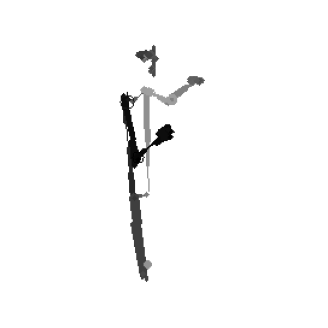

In [11]:
skeleton = construct_skeleton_from_mediapipe_result(
    detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.2,
)

stylized_skel = stylize_as_sketch(skeleton)
plt.figure(figsize=(4, 4))
plt.imshow(stylized_skel.render())
plt.axis("off")
plt.show()

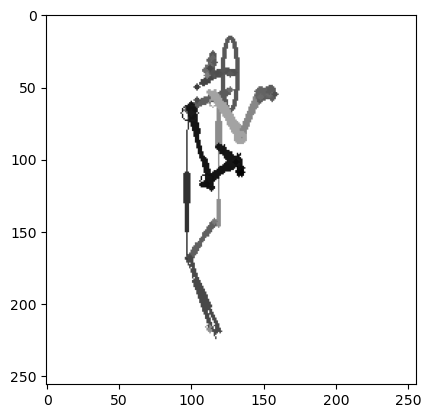

In [12]:
skeleton.jitter_joints(sigma=0.02)
plt.imshow(skeleton.render())

# Creating Heatmaps

In [13]:

def draw_gaussian(heatmap, x, y, H, W, sigma=2):
    for i in range(H):
        for j in range(W):
            heatmap[i,j] = np.exp(-((i-y)**2 + (j-x)**2)/(2*sigma**2))

In [14]:
import numpy as np

def construct_bounded_gaussian_from_landmarks(
    detection_result,
    edges,
    H=64,
    W=64,
    base_sigma=3.0,
    normalize_to_bbox=True,
    bbox_padding=0.15,
):
    """
    Returns:
        heatmaps: (33, H, W)
        visibility: (33,) visibility scores
    """

    skeleton = construct_skeleton_from_mediapipe_result(
        detection_result,
        edges,
        normalize_to_bbox=normalize_to_bbox,
        bbox_padding=bbox_padding,
    )

    joints = skeleton.joints  # (33,3)
    joint_meta = skeleton.joint_meta

    num_joints = joints.shape[0]
    heatmaps = np.zeros((num_joints, H, W), dtype=np.float32)
    visibility = np.zeros(num_joints, dtype=np.float32)

    z_vals = joints[:, 2]
    z_min, z_max = z_vals.min(), z_vals.max()
    z_norm = (z_vals - z_min) / (z_max - z_min + 1e-6)
    depth_weights = 1.0 - z_norm  # closer = stronger

    y_grid, x_grid = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    for i in range(num_joints):
        vis = joint_meta[i].get("visibility", 1.0)
        visibility[i] = vis

        x, y = joints[i, 0], joints[i, 1]

        # convert normalized → pixel
        px = x * (W - 1)
        py = y * (H - 1)

        # A. Amplitude (confidence)
        amplitude = vis ** 2  # emphasize confident joints

        # blend visibility + depth
        weight = 0.7 * vis + 0.3 * depth_weights[i]

        # B. Adaptive sigma (uncertainty)
        # low visibility → larger sigma (more uncertainty)
        sigma = base_sigma * (1.0 + (1.0 - vis) * 2.0)

        # Optional: boost ambiguous joints (shoulders/hips)
        joint_name = joint_meta[i].get("name", "")
        if joint_name in ["left_shoulder", "right_shoulder", "left_hip", "right_hip"]:
            sigma *= 1.3

        # C. Gaussian
        d2 = (x_grid - px) ** 2 + (y_grid - py) ** 2
        gaussian = np.exp(-d2 / (2 * sigma ** 2))

        # D. Apply weights
        gaussian *= amplitude * weight

        # Optional: suppress very weak tails
        gaussian[gaussian < 1e-3] = 0.0

        heatmaps[i] = gaussian

    return heatmaps, visibility

In [15]:
def show_single_heatmap(heatmaps, joint_idx):
    plt.imshow(heatmaps[joint_idx], cmap='hot')
    plt.title(f"Joint {joint_idx}")
    plt.colorbar()
    plt.show()

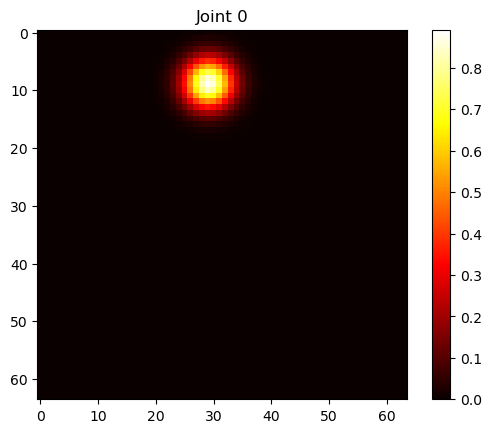

In [16]:
heatmap, visibility = construct_bounded_gaussian_from_landmarks(
    detection_result, edges)
show_single_heatmap(heatmap, joint_idx=0)

In [17]:
def overlay_heatmap_on_image(image, heatmap, alpha=0.6):
    """
    image: (H,W) or (H,W,3)
    heatmap: (H,W)
    """
    import cv2

    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]  # RGB

    if len(image.shape) == 2:
        image = np.stack([image]*3, axis=-1) / 255.0
    else:
        image = image / 255.0

    overlay = (1 - alpha) * image + alpha * heatmap_color
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

In [18]:
def show_all_heatmaps(heatmaps):
    combined = np.sum(heatmaps, axis=0)
    plt.imshow(combined, cmap='hot')
    plt.title("All joints combined")
    plt.colorbar()
    plt.show()

In [19]:
def plot_joints_on_image(image, heatmaps):
    import cv2

    H, W = heatmaps.shape[1:]
    img = image.copy()

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    for i in range(heatmaps.shape[0]):
        hm = heatmaps[i]
        y, x = np.unravel_index(np.argmax(hm), hm.shape)

        x_img = int(x * image.shape[1] / W)
        y_img = int(y * image.shape[0] / H)

        cv2.circle(img, (x_img, y_img), 3, (255, 0, 0), 1)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

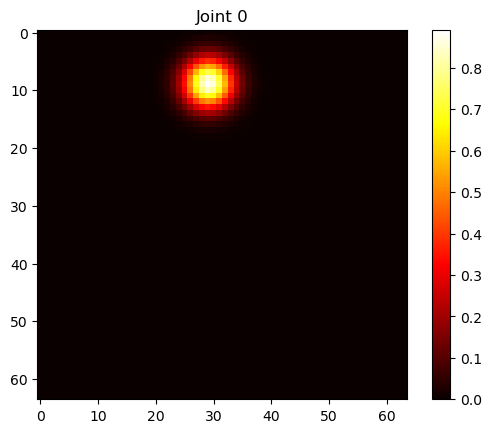

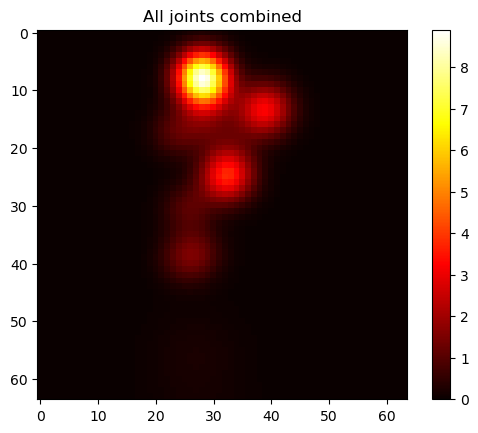

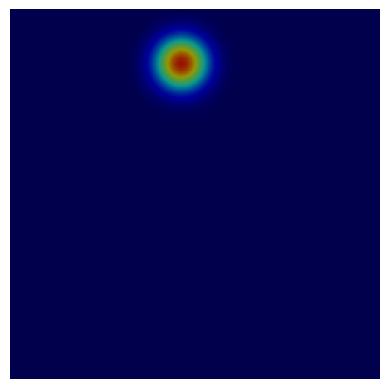

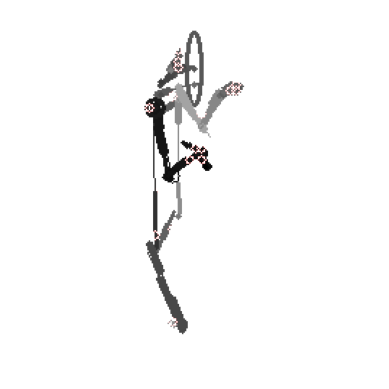

In [20]:
heatmaps, visibility = construct_bounded_gaussian_from_landmarks(detection_result, edges)
sketch_img = stylized_skel.render()

show_single_heatmap(heatmaps, 0)
show_all_heatmaps(heatmaps)
overlay_heatmap_on_image(sketch_img[:,:,:3], heatmaps[0])
plot_joints_on_image(sketch_img, heatmaps)

# Create Dataset

In [21]:
import random

def random_augment(sketch, heatmap):
    # sketch: (3, H, W), heatmap: (J, H, W)
    # Horizontal flip
    if random.random() < 0.5:
        sketch = np.flip(sketch, axis=2).copy()
        heatmap = np.flip(heatmap, axis=2).copy()

    # Random rotation
    angle = random.uniform(-30, 30)
    if abs(angle) > 1e-2:
        center = (sketch.shape[2] // 2, sketch.shape[1] // 2)
        rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
        for c in range(sketch.shape[0]):
            sketch[c] = cv2.warpAffine(
                sketch[c], rot_mat, (sketch.shape[2], sketch.shape[1]),
                flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT
            )
        for j in range(heatmap.shape[0]):
            heatmap[j] = cv2.warpAffine(
                heatmap[j], rot_mat, (heatmap.shape[2], heatmap.shape[1]),
                flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT
            )

    # Random scaling
    scale = random.uniform(0.8, 1.2)
    if abs(scale - 1.0) > 1e-2:
        h, w = sketch.shape[1:]
        nh, nw = max(1, int(h * scale)), max(1, int(w * scale))

        # Resize into new arrays first (do not write resized data into fixed-size arrays)
        sketch_scaled = np.stack([
            cv2.resize(sketch[c], (nw, nh), interpolation=cv2.INTER_LINEAR)
            for c in range(sketch.shape[0])
        ], axis=0)
        heatmap_scaled = np.stack([
            cv2.resize(heatmap[j], (nw, nh), interpolation=cv2.INTER_LINEAR)
            for j in range(heatmap.shape[0])
        ], axis=0)

        def center_crop_or_pad_3d(arr, out_h, out_w):
            # arr: (C, H, W)
            _, ah, aw = arr.shape

            if ah > out_h:
                top = (ah - out_h) // 2
                arr = arr[:, top:top + out_h, :]
            elif ah < out_h:
                pad_top = (out_h - ah) // 2
                pad_bottom = out_h - ah - pad_top
                arr = np.pad(arr, ((0, 0), (pad_top, pad_bottom), (0, 0)), mode='reflect')

            _, ah, aw = arr.shape
            if aw > out_w:
                left = (aw - out_w) // 2
                arr = arr[:, :, left:left + out_w]
            elif aw < out_w:
                pad_left = (out_w - aw) // 2
                pad_right = out_w - aw - pad_left
                arr = np.pad(arr, ((0, 0), (0, 0), (pad_left, pad_right)), mode='reflect')

            return arr

        sketch = center_crop_or_pad_3d(sketch_scaled, h, w)
        heatmap = center_crop_or_pad_3d(heatmap_scaled, h, w)

    return sketch, heatmap

In [22]:
def composite_sketch_on_white(sketch_rgba):
    """Blends an RGBA sketch onto a white background to create a standard RGB image."""
    white_bg = np.ones_like(sketch_rgba[:, :, :3]) * 255
    alpha = sketch_rgba[:, :, 3:] / 255.0
    sketch_rgb = sketch_rgba[:, :, :3]
    final_rgb = (sketch_rgb * alpha + white_bg * (1.0 - alpha))
    return final_rgb.astype(np.uint8)


def create_dataset_from_csv(series, output_folder, edges, sample_limit=5, image_base_path="", apply_aug=True):
    """
    series: pandas Series containing image file names/paths.
    image_base_path: optional base path to prepend to values from series.
    apply_aug: if True, apply paired sketch/heatmap augmentation before saving.
    """
    # Import tqdm here to ensure it's always the callable function within this scope
    from tqdm import tqdm

    base_options = python.BaseOptions(model_asset_path=f"{PATH}/pose_landmarker_full.task")
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True,
    )
    detector = vision.PoseLandmarker.create_from_options(options)

    output_root = Path(output_folder)
    print(f"this is the output folder {output_folder}")
    print(f"this is the output root {output_root}")

    # Renamed directories to clarify they hold data, not images
    heatmap_dir = output_root / "heatmaps_pkl"
    sketch_dir = output_root / "sketches_pkl"
    visibility_dir = output_root / "visibility_pkl"
    heatmap_dir.mkdir(parents=True, exist_ok=True)
    sketch_dir.mkdir(parents=True, exist_ok=True)
    visibility_dir.mkdir(parents=True, exist_ok=True)

    base_path = Path(image_base_path) if image_base_path else None

    # List to hold the mapping rows for the CSV
    dataset_mapping = []

    for idx, (key, row) in enumerate(tqdm(series.items(), total=len(series))):
        img_filename = str(row).strip()
        if not img_filename or img_filename.lower() == "nan":
            continue

        image_path = (base_path / img_filename) if base_path else Path(img_filename)

        if not image_path.exists():
            print(f"Warning: missing file, skipping: {image_path}")
            continue

        try:
            image = mp.Image.create_from_file(str(image_path))
            detection_result = detector.detect(image)
        except Exception as e:
            print(f"Warning: failed to read/detect {image_path}: {e}")
            continue

        if not detection_result.pose_landmarks:
            print(f"Warning: no pose detected, skipping: {image_path.name}")
            continue

        try:
            skeleton = construct_skeleton_from_mediapipe_result(
                detection_result,
                edges,
                normalize_to_bbox=True,
                bbox_padding=0.2,
            )
            heatmaps, visibility = construct_bounded_gaussian_from_landmarks(detection_result, edges)
        except Exception as e:
            print(f"Warning: failed to build skeleton/heatmaps for {image_path.name}: {e}")
            continue
        
        visible_score = float(visibility.mean())  # 0–1 average across all joints
        
        if visible_score < 0.3:  # hard cutoff for very poor samples
            print(f"Warning: low visibility score ({visible_score:.2f}), skipping: {image_path.name}")
            continue
        
        stem = Path(img_filename).stem

        for i in range(sample_limit):
            stylized_skel = stylize_as_sketch(skeleton)
            sketch_matrix_rgba = stylized_skel.render()

            if sketch_matrix_rgba.ndim == 3 and sketch_matrix_rgba.shape[2] == 4:
                sketch_matrix = composite_sketch_on_white(sketch_matrix_rgba)
            else:
                sketch_matrix = sketch_matrix_rgba

            # Keep sketch/heatmap paired by applying the same random transform to both
            heatmap_to_save = heatmaps.copy()
            sketch_matrix = cv2.resize(sketch_matrix, (64, 64), interpolation=cv2.INTER_AREA)

            if apply_aug:
                sketch_64 = cv2.resize(sketch_matrix, (64, 64), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0
                sketch_chw = np.transpose(sketch_64, (2, 0, 1))
                sketch_chw, heatmap_to_save = random_augment(sketch_chw, heatmap_to_save.copy())
                sketch_matrix = np.transpose(sketch_chw, (1, 2, 0))
                sketch_matrix = np.clip(sketch_matrix * 255.0, 0, 255).astype(np.uint8)

            sketch_output_path = sketch_dir / f"{stem}_{i}.pkl"
            heatmap_output_path = heatmap_dir / f"{stem}_{i}.pkl"
            visibility_output_path = visibility_dir / f"{stem}_{i}.pkl"

            # Save paired sketch + heatmap arrays and the original landmark visibility.
            with open(sketch_output_path, "wb") as f:
                pkl.dump(sketch_matrix, f)
            with open(heatmap_output_path, "wb") as f:
                pkl.dump(heatmap_to_save.astype(np.float32), f)
            with open(visibility_output_path, "wb") as f:
                pkl.dump(visibility.astype(np.float32), f)

            skeleton.jitter_joints(sigma=0.02)

            # Record the relationship in our list
            dataset_mapping.append({
                "input_sketch_pkl": str(sketch_output_path),
                "output_heatmap_pkl": str(heatmap_output_path),
                "visibility_pkl": str(visibility_output_path)
            })

        # Save dataset_mapping to CSV every 1000 rows
        if (idx + 1) % 1000 == 0:
            csv_path_partial = output_root / f"dataset_mapping_{idx+1}.csv"
            df_partial = pd.DataFrame(dataset_mapping)
            df_partial.to_csv(csv_path_partial, index=False)
            print(f"Partial mapping saved to: {csv_path_partial}")

    # Convert the list of dictionaries to a DataFrame and save as CSV
    csv_path = output_root / "dataset_mapping.csv"
    df = pd.DataFrame(dataset_mapping)
    df.to_csv(csv_path, index=False)

    print(f"Dataset generation complete. Mapping saved to: {csv_path}")
    return df


In [90]:
df = pd.read_csv(f"{PATH}/data.csv")
dataset_map = create_dataset_from_csv(
    df["img_paths"],
    f"{PATH}/CNN_data",
    edges,
    image_base_path=f"{PATH}/mpii_human_pose_v1/images",
)
len(dataset_map)

this is the output folder C:/Users/leahz/Documents/ATC/pose-project/data/CNN_data
this is the output root C:\Users\leahz\Documents\ATC\pose-project\data\CNN_data


  0%|          | 3/11503 [00:00<21:54,  8.75it/s]

  0%|          | 13/11503 [00:01<25:20,  7.56it/s]

  0%|          | 17/11503 [00:02<26:10,  7.31it/s]

  0%|          | 25/11503 [00:03<26:12,  7.30it/s]

...

100%|█████████▉| 11484/11503 [1:00:28<00:02,  7.63it/s]

100%|█████████▉| 11491/11503 [1:00:29<00:01,  7.37it/s]

100%|██████████| 11503/11503 [1:00:31<00:00,  3.17it/s]


Dataset generation complete. Mapping saved to: C:\Users\leahz\Documents\ATC\pose-project\data\CNN_data\dataset_mapping.csv


52730

# Model

In [23]:
import torch
import random
import numpy as np
import cv2
from torch.utils.data import Dataset
import pickle as pkl
import tqdm
from pathlib import Path

class SketchPoseDataset(Dataset):
    def __init__(self, csv_path, preload=True, cache_pt_path=None, rebuild_cache=False, augment=False):
        self.df = pd.read_csv(csv_path)
        self.preload = preload
        self._cache = []
        self.cache_pt_path = Path(cache_pt_path) if cache_pt_path else None
        self.augment = augment

        if not self.preload:
            return

        if self.cache_pt_path and self.cache_pt_path.exists() and not rebuild_cache:
            self._cache = torch.load(self.cache_pt_path, map_location="cpu")
            print(f"Loaded cached tensors: {self.cache_pt_path} ({len(self._cache)} samples)")
            return

        for row in tqdm.tqdm(self.df.itertuples(index=False), total=len(self.df), desc="Preloading sketches/heatmaps"):
            sketch, heatmap, visibility = self._load_pair(row.input_sketch_pkl, row.output_heatmap_pkl, getattr(row, "visibility_pkl", None))
            self._cache.append((sketch, heatmap, visibility))

        if self.cache_pt_path:
            self.cache_pt_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(self._cache, self.cache_pt_path)
            print(f"Saved dataset tensor cache: {self.cache_pt_path}")

    def __len__(self):
        return len(self.df)

    def _load_pair(self, sketch_path, heatmap_path, visibility_path=None):
        with open(sketch_path, "rb") as f:
            sketch = pkl.load(f)

        with open(heatmap_path, "rb") as f:
            heatmap = pkl.load(f)

        if visibility_path and Path(visibility_path).exists():
            with open(visibility_path, "rb") as f:
                visibility = pkl.load(f)
            visibility = np.array(visibility, dtype=np.float32)
        else:
            # Backward-compatible fallback for older CSVs that do not store visibility explicitly.
            heatmap_arr = np.array(heatmap, dtype=np.float32)
            visibility = (heatmap_arr.max(axis=(1,2)) > 0.01).astype(np.float32)

        sketch = np.array(sketch)
        if sketch.ndim == 2:
            sketch = np.stack([sketch, sketch, sketch], axis=-1)
        elif sketch.ndim == 3 and sketch.shape[2] == 4:
            sketch = sketch[:, :, :3]

        sketch = cv2.resize(sketch, (64, 64), interpolation=cv2.INTER_AREA)
        sketch = sketch.astype(np.float32) / 255.0
        heatmap = np.array(heatmap, dtype=np.float32)

        sketch_t = torch.tensor(sketch).permute(2, 0, 1)
        heatmap_t = torch.tensor(heatmap).float()
        visibility_t = torch.tensor(visibility).float()
        return sketch_t, heatmap_t, visibility_t

    def __getitem__(self, idx):
        if self.preload:
            sketch, heatmap, visibility = self._cache[idx]
        else:
            row = self.df.iloc[idx]
            sketch, heatmap, visibility = self._load_pair(
                row["input_sketch_pkl"],
                row["output_heatmap_pkl"],
                row["visibility_pkl"] if "visibility_pkl" in self.df.columns else None,
            )
        # --- Data augmentation ---
        if self.augment:
            sketch_np = sketch.numpy()
            heatmap_np = heatmap.numpy()
            sketch_np, heatmap_np = random_augment(sketch_np, heatmap_np)
            sketch = torch.tensor(sketch_np)
            heatmap = torch.tensor(heatmap_np)
        return sketch, heatmap, visibility

In [24]:
import torch
import os
import tqdm

def build_dataset_cache_chunked(dataset, save_dir, chunk_size=500):
    os.makedirs(save_dir, exist_ok=True)

    images = []
    labels = []
    visibility = []
    chunk_idx = 0

    print("Building chunked dataset cache...")

    for i in tqdm.tqdm(range(len(dataset))):
        x, y, v = dataset[i]

        images.append(x)
        labels.append(y)
        visibility.append(v)

        if len(images) == chunk_size:
            save_chunk(images, labels, visibility, save_dir, chunk_idx)
            images, labels, visibility = [], [], []
            chunk_idx += 1

    # Save remaining
    if images:
        save_chunk(images, labels, visibility, save_dir, chunk_idx)

    print("Done")


def save_chunk(images, labels, visibility, save_dir, chunk_idx):
    images = torch.stack(images)
    labels = torch.stack(labels)
    visibility = torch.stack(visibility)

    path = os.path.join(save_dir, f"chunk_{chunk_idx}.pt")
    torch.save({"images": images, "labels": labels, "visibility": visibility}, path)

    print(f"Saved chunk {chunk_idx} -> {path}")

In [93]:
raw_dataset = SketchPoseDataset(
    f"{PATH}/CNN_data/dataset_mapping.csv",
    preload=False,
    augment=False  # keep cache deterministic; augmentation is baked into create_dataset_from_csv
 )

build_dataset_cache_chunked(
    raw_dataset,
    save_dir=f"{PATH}/dataset_cache"
 )

Building chunked dataset cache...


  1%|          | 582/52730 [00:02<07:10, 121.04it/s]

Saved chunk 0 -> C:/Users/leahz/Documents/ATC/pose-project/data/dataset_cache\chunk_0.pt


  2%|▏         | 1051/52730 [00:04<04:23, 196.00it/s]

Saved chunk 1 -> C:/Users/leahz/Documents/ATC/pose-project/data/dataset_cache\chunk_1.pt


...

Saved chunk 103 -> C:/Users/leahz/Documents/ATC/pose-project/data/dataset_cache\chunk_103.pt


100%|█████████▉| 52565/52730 [02:54<00:00, 236.51it/s]

Saved chunk 104 -> C:/Users/leahz/Documents/ATC/pose-project/data/dataset_cache\chunk_104.pt


100%|██████████| 52730/52730 [02:54<00:00, 301.55it/s]


Saved chunk 105 -> C:/Users/leahz/Documents/ATC/pose-project/data/dataset_cache\chunk_105.pt
Done


In [25]:
class ChunkedDataset(torch.utils.data.Dataset):
    def __init__(self, chunk_dir, shuffle_chunks=False, seed=42, max_chunks=None):
        self.chunk_files = sorted([
            os.path.join(chunk_dir, f)
            for f in os.listdir(chunk_dir)
            if f.endswith(".pt")
        ])

        if max_chunks is not None:
            if max_chunks <= 0:
                raise ValueError("max_chunks must be a positive integer or None")
            self.chunk_files = self.chunk_files[:max_chunks]

        if shuffle_chunks:
            rng = random.Random(seed)
            rng.shuffle(self.chunk_files)  # shuffle chunk order, not samples

        self.chunk_sizes = []
        self.cumulative_sizes = []

        total = 0
        for file in self.chunk_files:
            data = torch.load(file, map_location="cpu")
            size = len(data["images"])
            self.chunk_sizes.append(size)
            total += size
            self.cumulative_sizes.append(total)

        self.current_chunk_idx = -1
        self.current_chunk = None

    def __len__(self):
        return self.cumulative_sizes[-1]

    def _load_chunk(self, chunk_idx):
        if self.current_chunk_idx != chunk_idx:
            self.current_chunk = torch.load(
                self.chunk_files[chunk_idx],
                map_location="cpu"
            )
            self.current_chunk_idx = chunk_idx

    def get_all_visibility(self):
        """Fast path for sampler weights: load only visibility tensors from each chunk."""
        vis_list = []
        for chunk_file in self.chunk_files:
            chunk = torch.load(chunk_file, map_location="cpu")
            vis = chunk["visibility"]
            if isinstance(vis, torch.Tensor):
                vis = vis.numpy()
            vis_list.append(np.asarray(vis, dtype=np.float32))
        return np.concatenate(vis_list, axis=0)

    def __getitem__(self, idx):
        for i, size in enumerate(self.cumulative_sizes):
            if idx < size:
                self._load_chunk(i)
                prev = 0 if i == 0 else self.cumulative_sizes[i - 1]
                local_idx = idx - prev
                return (
                    self.current_chunk["images"][local_idx],
                    self.current_chunk["labels"][local_idx],
                    self.current_chunk["visibility"][local_idx]
                )

In [26]:
from torch.utils.data import TensorDataset, DataLoader, random_split, WeightedRandomSampler
import numpy as np
import os

CHUNK_PATH = f"{PATH}/dataset_cache"
MAX_CHUNKS_TO_USE = 10

dataset = ChunkedDataset(
    CHUNK_PATH,
    shuffle_chunks=True,
    seed=42,
    max_chunks=MAX_CHUNKS_TO_USE,
 )

seed = 42
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
split_gen = torch.Generator().manual_seed(seed)

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=split_gen
 )

# Fast visibility loading: use cache when available, otherwise build once from chunk tensors.
vis_cache = os.path.join(CHUNK_PATH, "visibility_all.npy")
if os.path.exists(vis_cache):
    all_visibility = np.load(vis_cache).astype(np.float32)
else:
    print("Building visibility cache (one-time cost)...")
    all_visibility = dataset.get_all_visibility().astype(np.float32)
    np.save(vis_cache, all_visibility)
    print(f"Saved visibility cache to: {vis_cache}")

train_indices = np.asarray(train_dataset.indices, dtype=np.int64)
train_visibility = all_visibility[train_indices]  # (num_train_samples, num_joints)

joint_counts = train_visibility.sum(axis=0)
joint_weights = 1.0 / (joint_counts + 1e-6)
sample_weights = (train_visibility * joint_weights).sum(axis=1)
sample_weights = np.clip(sample_weights, a_min=1e-8, a_max=None)
sample_weights_t = torch.tensor(sample_weights, dtype=torch.double)

train_sampler = WeightedRandomSampler(
    weights=sample_weights_t,
    num_samples=len(sample_weights_t),
    replacement=True,
 )

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    sampler=train_sampler,
    num_workers=0,
    pin_memory=pin_memory,
    persistent_workers=False
 )
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
    persistent_workers=False
 )

print(f"Chunks used: {len(dataset.chunk_files)}")
print(f"Dataset size: {len(dataset)}")
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Weighted sampler active: {len(sample_weights_t)} training samples")
print(f"Visibility cache: {vis_cache}")

Chunks used: 10
Dataset size: 4730
Train size: 3784
Test size: 946
Weighted sampler active: 3784 training samples
Visibility cache: C:/Users/leahz/Documents/ATC/pose-project/data/dataset_cache\visibility_all.npy


In [27]:
def plot_heatmaps(pred, target, joint_idx=0):
    # pred, target: (J, H, W)
    
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(target[joint_idx].detach().cpu().numpy(), cmap='hot')
    plt.title("Target")
    plt.subplot(1,2,2)
    plt.imshow(pred[joint_idx].detach().cpu().numpy(), cmap='hot')
    plt.title("Prediction")
    plt.show()


In [28]:
# Joint weights — emphasize torso joints
JOINT_WEIGHTS = torch.ones(33)
JOINT_WEIGHTS[11] = 3.0  # left shoulder
JOINT_WEIGHTS[12] = 3.0  # right shoulder
JOINT_WEIGHTS[23] = 3.0  # left hip
JOINT_WEIGHTS[24] = 3.0  # right hip

# Bone connections for structural loss
BONES = [
    # torso
    (12, 11), (24, 23), (12, 24), (11, 23),
    # left leg
    (24, 26), (26, 28),
    # right leg
    (23, 25), (25, 27),
    # left arm
    (12, 14), (14, 16),
    # right arm
    (11, 13), (13, 15),
    # head
    (8, 7), (10, 9),
]

def masked_per_joint_loss(
    pred, target, visibility,
    vis_pred,                        # (B, J) — model's predicted visibility
    coord_weight=0.25,
    bone_weight=0.5,
    vis_weight=0.125,                  # weight for visibility BCE loss
    use_pred_vis_for_coord=True,     # mirror pose_distance: weight by min(pred, gt)
):
    b, j, h, w = pred.shape
    jw = JOINT_WEIGHTS.to(pred.device)  # (J,)

    # ------------------------------------------------------------------
    # 1. Visibility supervision (BCE)
    # ------------------------------------------------------------------
    vis_loss = F.binary_cross_entropy(vis_pred, visibility, reduction='none')
    vis_loss = vis_loss.mean(dim=0)  # per joint
    num_visible = visibility.sum()
    vis_loss = vis_loss.sum() / (num_visible + 1e-6)

    # ------------------------------------------------------------------
    # 2. Effective per-joint visibility weight
    #    Mirrors pose_distance: vv = min(vis1[i], vis2[i])
    #    Here: "predicted confidence" vs "ground truth presence"
    # ------------------------------------------------------------------
    if use_pred_vis_for_coord:
        # Soft weight: joint matters only if both GT says visible
        # AND model is confident — mirrors the min() in pose_distance
        eff_vis = torch.min(vis_pred, visibility)          # (B, J)
    else:
        eff_vis = visibility                               # original behaviour

    # ------------------------------------------------------------------
    # 3. Heatmap MSE loss (unchanged, uses GT visibility for masking)
    # ------------------------------------------------------------------
    mse = ((pred - target) ** 2 * (1 + 5 * target)).view(b, j, -1).mean(-1)  # (B, J)
    mse = mse * jw.unsqueeze(0)
    vis_denom = visibility.sum(-1) + 1e-6                 # (B,) — keep GT denom here
    heatmap_loss = (mse * visibility).sum(-1) / vis_denom
    heatmap_loss = heatmap_loss.mean()

    # ------------------------------------------------------------------
    # 4. Coordinate extraction
    # ------------------------------------------------------------------
    def soft_argmax(heatmap):
        h_idx = torch.linspace(0, 1, h, device=heatmap.device)
        w_idx = torch.linspace(0, 1, w, device=heatmap.device)
        sm = F.softmax(heatmap.view(b, j, -1) / 0.1, dim=-1).view(b, j, h, w)
        x = (sm.sum(-2) * w_idx).sum(-1)
        y = (sm.sum(-1) * h_idx).sum(-1)
        return torch.stack([x, y], dim=-1)  # (B, J, 2)


    pred_coords   = soft_argmax(pred)      # (B, J, 2)
    target_coords = soft_argmax(target)    # (B, J, 2)

    # ------------------------------------------------------------------
    # 5. Weighted coordinate loss — uses eff_vis (mirrors pose_distance)
    #    Distance is L2; weight = min(pred_vis, gt_vis) * joint_weight
    # ------------------------------------------------------------------
    coord_dist = torch.norm(pred_coords - target_coords, dim=-1)   # (B, J)  ← L2, like pose_distance
    coord_dist = coord_dist * jw.unsqueeze(0)                      # joint importance

    eff_denom  = eff_vis.sum(-1) + 1e-6                            # (B,)
    coord_loss = (coord_dist * eff_vis).sum(-1) / eff_denom        # visibility-weighted mean
    coord_loss = coord_loss.mean()

    # ------------------------------------------------------------------
    # 6. Bone structural loss — also uses eff_vis for both endpoints
    #    Mirrors: bone_vis = vis_a * vis_b (but soft now)
    # ------------------------------------------------------------------
    bone_loss = torch.tensor(0.0, device=pred.device)
    num_valid_bones = 0

    for (a, b_idx) in BONES:
        # Soft bone visibility: both endpoints must be confidently visible
        bone_vis = eff_vis[:, a] * eff_vis[:, b_idx]   # (B,) — product mirrors min() chained

        if bone_vis.sum() < 1e-6:
            continue

        pred_vec   = pred_coords[:, a, :]   - pred_coords[:, b_idx, :]
        target_vec = target_coords[:, a, :] - target_coords[:, b_idx, :]

        pred_len   = torch.norm(pred_vec,   dim=-1)
        target_len = torch.norm(target_vec, dim=-1)

        length_diff = ((pred_len - target_len) ** 2) * bone_vis
        bone_loss  += length_diff.sum() / (bone_vis.sum() + 1e-6)
        num_valid_bones += 1

    if num_valid_bones > 0:
        bone_loss = bone_loss / num_valid_bones

    # ------------------------------------------------------------------
    # 7. Total loss
    # ------------------------------------------------------------------
    total = (
        heatmap_loss * .125
        + coord_weight * coord_loss
        + bone_weight  * bone_loss
        + vis_weight   * vis_loss
    )
    return total, {
        "heatmap": heatmap_loss.item(),
        "coord":   coord_loss.item(),
        "bone":    bone_loss.item(),
        "vis":     vis_loss.item(),
    }

In [29]:
class PoseCNN(nn.Module):
    def __init__(self, num_keypoints=33):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, num_keypoints, 1),
            nn.Sigmoid()
        )

        # Visibility head: pool encoder features → per-joint score
        self.visibility_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),        # (B, 256, 4, 4)
            nn.Flatten(),                         # (B, 256*16)
            nn.Linear(256 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_keypoints),
            nn.Sigmoid()                          # (B, J) in [0, 1]
        )

    def forward(self, x):
        enc = self.encoder(x)
        heatmaps = self.decoder(enc)
        vis_pred = self.visibility_head(enc)     # (B, J)
        return heatmaps, vis_pred

In [30]:
import re
def _extract_epoch_from_filename(filename):
    match = re.search(r"epoch_(\d+)", os.path.basename(filename))
    if match:
        return int(match.group(1))
    return 0


def train_pose(
    filename="",
    num_epochs=100,
    seed=42,
    learning_rate=5e-4,
    save_every=10,
    log_every=10,
):
    # --- Seed ---
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # --- Device ---
    device = "cuda" if torch.cuda.is_available() else "cpu"


    model = PoseCNN(num_keypoints=33)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    checkpoint_dir = f"{PATH}/models"
    os.makedirs(checkpoint_dir, exist_ok=True)

    start_epoch = 0
    resume_path = ""
    if isinstance(filename, str) and filename.strip():
        resume_path = f"{checkpoint_dir}/{filename.strip()}"

    if resume_path:
        checkpoint = torch.load(resume_path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        if "optimizer_state_dict" in checkpoint:
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        # Prefer the epoch stored in checkpoint; fallback to parsing from filename.
        start_epoch = int(checkpoint.get("epoch", 0))
        if start_epoch <= 0:
            start_epoch = _extract_epoch_from_filename(resume_path)

        print(f"Resuming training from checkpoint: {resume_path}")
        print(f"Starting from epoch {start_epoch + 1} of {num_epochs}")

    # Force requested LR even when optimizer state was loaded from checkpoint.
    for param_group in optimizer.param_groups:
        param_group["lr"] = learning_rate

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=1e-5,
    )

    # Align scheduler epoch position when resuming.
    if start_epoch > 0:
        scheduler.last_epoch = start_epoch - 1
        scheduler.base_lrs = [learning_rate for _ in optimizer.param_groups]

    if start_epoch >= num_epochs:
        print(f"Checkpoint is already at/after target num_epochs={num_epochs}. Nothing to train.")
        return model

    for epoch in tqdm.tqdm(range(start_epoch, num_epochs)):
        model.train()
        total_loss = 0.0
        total_heatmap = 0.0
        total_coord = 0.0
        total_bone = 0.0
        total_vis = 0.0

        for batch_idx, (x, y, visibility) in enumerate(train_loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            visibility = visibility.to(device, non_blocking=True)

            heatmaps, vis_pred = model(x)
            loss, breakdown = masked_per_joint_loss(
                heatmaps, y, visibility, vis_pred
            )

            optimizer.zero_grad()
            loss.backward()

            # --- Gradient norm (debugging) ---
            total_grad_norm = 0
            if batch_idx % log_every == 0:
                total_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float('inf')).item()

            optimizer.step()

            total_loss += loss.item()
            total_heatmap += breakdown["heatmap"]
            total_coord += breakdown["coord"]
            total_bone += breakdown["bone"]
            total_vis += breakdown["vis"]

            # --- Batch logging ---
            if batch_idx % log_every == 0:
                current_lr = optimizer.param_groups[0]["lr"]
                print(
                    f"Epoch [{epoch+1}/{num_epochs}] ",
                    f"Batch [{batch_idx}/{len(train_loader)}] ",
                    f"Loss: {loss.item():.6f} ",
                    f"HM: {breakdown['heatmap']:.6f} ",
                    f"Coord: {breakdown['coord']:.6f} ",
                    f"Bone: {breakdown['bone']:.6f} ",
                    f"Vis: {breakdown['vis']:.6f} ",
                    f"GradNorm: {total_grad_norm:.4f} ",
                    f"LR: {current_lr}"
                )

        scheduler.step()

        num_batches = max(len(train_loader), 1)
        avg_loss = total_loss / num_batches
        avg_heatmap = total_heatmap / num_batches
        avg_coord = total_coord / num_batches
        avg_bone = total_bone / num_batches
        avg_vis = total_vis / num_batches
        current_epoch = epoch + 1

        print(f"\nEpoch {current_epoch} Summary:")
        print(f"Avg Loss: {avg_loss:.6f}")
        print(
            f"Avg Breakdown -> HM: {avg_heatmap:.6f}, "
            f"Coord: {avg_coord:.6f}, "
            f"Bone: {avg_bone:.6f}, "
            f"Vis: {avg_vis:.6f}\n"
        )
        print(f"Scheduler LR after epoch {current_epoch}: {scheduler.get_last_lr()[0]:.8f}")

        if current_epoch % save_every == 0:
            checkpoint_path = f"{checkpoint_dir}/pose_model_added_visibility_epoch_{current_epoch}.pth"
            torch.save({
                "epoch": current_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "num_keypoints": 33,
                "avg_loss": avg_loss,
                "avg_heatmap": avg_heatmap,
                "avg_coord": avg_coord,
                "avg_bone": avg_bone,
                "avg_vis": avg_vis,
                "seed": seed,
            }, checkpoint_path)

            print(f"Saved checkpoint: {checkpoint_path}")

    return model


In [65]:
train_pose(filename="pose_model_added_visibility_epoch_40.pth", learning_rate=1e-4)

Resuming training from checkpoint: C:/Users/leahz/Documents/ATC/pose-project/data/models/pose_model_added_visibility_epoch_40.pth
Starting from epoch 41 of 100


  0%|          | 0/60 [00:00<?, ?it/s]

Epoch [41/100]  Batch [0/474]  Loss: 0.025845  HM: 0.009268  Coord: 0.089178  Bone: 0.004744  Vis: 0.000161  GradNorm: 0.0603  LR: 0.0001
Epoch [41/100]  Batch [10/474]  Loss: 0.030129  HM: 0.009050  Coord: 0.100499  Bone: 0.006940  Vis: 0.003229  GradNorm: 0.0746  LR: 0.0001
Epoch [41/100]  Batch [20/474]  Loss: 0.028743  HM: 0.010558  Coord: 0.096014  Bone: 0.006252  Vis: 0.002351  GradNorm: 0.1130  LR: 0.0001
Epoch [41/100]  Batch [30/474]  Loss: 0.028481  HM: 0.010709  Coord: 0.100004  Bone: 0.003838  Vis: 0.001782  GradNorm: 0.0770  LR: 0.0001
Epoch [41/100]  Batch [40/474]  Loss: 0.025964  HM: 0.010558  Coord: 0.085018  Bone: 0.006141  Vis: 0.002553  GradNorm: 0.1002  LR: 0.0001
Epoch [41/100]  Batch [50/474]  Loss: 0.026044  HM: 0.011064  Coord: 0.090351  Bone: 0.004140  Vis: 0.000027  GradNorm: 0.0736  LR: 0.0001
Epoch [41/100]  Batch [60/474]  Loss: 0.023448  HM: 0.009723  Coord: 0.082300  Bone: 0.003284  Vis: 0.000125  GradNorm: 0.0628  LR: 0.0001
Epoch [41/100]  Batch [70/47

  2%|▏         | 1/60 [08:42<8:33:22, 522.07s/it]


Epoch 41 Summary:
Avg Loss: 0.023513
Avg Breakdown -> HM: 0.010109, Coord: 0.079912, Bone: 0.004259, Vis: 0.001137

Scheduler LR after epoch 41: 0.00009800
Epoch [42/100]  Batch [0/474]  Loss: 0.019399  HM: 0.009526  Coord: 0.066851  Bone: 0.002834  Vis: 0.000625  GradNorm: 0.0734  LR: 9.800193653449298e-05
Epoch [42/100]  Batch [10/474]  Loss: 0.022169  HM: 0.010470  Coord: 0.070987  Bone: 0.005393  Vis: 0.003338  GradNorm: 0.0670  LR: 9.800193653449298e-05
Epoch [42/100]  Batch [20/474]  Loss: 0.019185  HM: 0.009909  Coord: 0.066112  Bone: 0.002702  Vis: 0.000537  GradNorm: 0.0772  LR: 9.800193653449298e-05
Epoch [42/100]  Batch [30/474]  Loss: 0.021064  HM: 0.008469  Coord: 0.072332  Bone: 0.003827  Vis: 0.000072  GradNorm: 0.0595  LR: 9.800193653449298e-05
Epoch [42/100]  Batch [40/474]  Loss: 0.024791  HM: 0.011562  Coord: 0.083209  Bone: 0.005066  Vis: 0.000079  GradNorm: 0.0647  LR: 9.800193653449298e-05
Epoch [42/100]  Batch [50/474]  Loss: 0.021929  HM: 0.009581  Coord: 0.073

  2%|▏         | 1/60 [11:06<10:54:58, 666.07s/it]


KeyboardInterrupt: 

In [31]:
import pickle as pkl
import numpy as np

df = pd.read_csv(f"{PATH}/CNN_data/dataset_mapping.csv")
with open(df["output_heatmap_pkl"].iloc[0], "rb") as f:
    hm = pkl.load(f)
hm = np.array(hm)
print("shape:", hm.shape)
print("max:", hm.max())
print("min:", hm.min())
print("mean:", hm.mean())

shape: (33, 64, 64)
max: 0.934682
min: 0.0
mean: 0.011433271


In [32]:
x, y, vis = next(iter(train_loader))
x = x.to(device)
with torch.no_grad():
    pred = model(x)
print("pred min:", pred.min().item())
print("pred max:", pred.max().item())
print("pred mean:", pred.mean().item())
print("target max:", y.max().item())

NameError: name 'device' is not defined

In [34]:
# Load a saved model
def load_model(model_path):
    checkpoint = torch.load(model_path, map_location=device)
    num_keypoints = checkpoint['num_keypoints']
    
    # Create a new model instance
    loaded_model = PoseCNN(num_keypoints=num_keypoints)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()  # Set to evaluation mode
    
    return loaded_model

# Example: load the model
# loaded_model = load_model(model_save_path)
# Now you can use loaded_model for inference

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = load_model(f"{PATH}/models/pose_model_added_visibility_epoch_80.pth")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


In [127]:
# Evaluate on test data after training
# "Accuracy" here is PCK-style: predicted joint heatmap peak must be within 3 pixels of target peak.
model.eval()

total_test_loss = 0.0
total_joints = 0
correct_joints = 0
pixel_tolerance = 3.0

with torch.no_grad():
    for x_test, y_test in tqdm.tqdm(test_loader):
        x_test, y_test = x_test.to(device), y_test.to(device)

        pred_test = model(x_test)
        batch_loss = criterion(pred_test, y_test)
        total_test_loss += batch_loss.item()

        bsz, num_joints, H, W = pred_test.shape

        pred_idx = pred_test.view(bsz, num_joints, -1).argmax(dim=-1)
        gt_idx = y_test.view(bsz, num_joints, -1).argmax(dim=-1)

        pred_y = (pred_idx // W).float()
        pred_x = (pred_idx % W).float()
        gt_y = (gt_idx // W).float()
        gt_x = (gt_idx % W).float()

        dists = torch.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)
        correct_joints += (dists <= pixel_tolerance).sum().item()
        total_joints += dists.numel()

avg_test_loss = total_test_loss / max(len(test_loader), 1)
test_accuracy = 100.0 * correct_joints / max(total_joints, 1)

print(f"Test loss (MSE): {avg_test_loss:.6f}")
print(f"Test 'accuracy' (PCK@{int(pixel_tolerance)}px): {test_accuracy:.2f}%")
print(f"Correct joints: {correct_joints}/{total_joints}")

  0%|          | 0/119 [00:02<?, ?it/s]


ValueError: too many values to unpack (expected 2)

In [ ]:
# Quick shape sanity check on train loader
x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
with torch.no_grad():
    pred_batch = model(x_batch)
print("pred shape:", tuple(pred_batch.shape))
print("target shape:", tuple(y_batch.shape))

In [ ]:
# Evaluate on test data after training
# "Accuracy" here is PCK-style: predicted joint heatmap peak must be within 3 pixels of target peak.
model.eval()

total_test_loss = 0.0
total_joints = 0
correct_joints = 0
pixel_tolerance = 3.0

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test, y_test = x_test.to(device), y_test.to(device)

        pred_test = model(x_test)
        batch_loss = criterion(pred_test, y_test)
        total_test_loss += batch_loss.item()

        bsz, num_joints, H, W = pred_test.shape

        pred_idx = pred_test.view(bsz, num_joints, -1).argmax(dim=-1)
        gt_idx = y_test.view(bsz, num_joints, -1).argmax(dim=-1)

        pred_y = (pred_idx // W).float()
        pred_x = (pred_idx % W).float()
        gt_y = (gt_idx // W).float()
        gt_x = (gt_idx % W).float()

        dists = torch.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)
        correct_joints += (dists <= pixel_tolerance).sum().item()
        total_joints += dists.numel()

avg_test_loss = total_test_loss / max(len(test_loader), 1)
test_accuracy = 100.0 * correct_joints / max(total_joints, 1)

print(f"Test loss (MSE): {avg_test_loss:.6f}")
print(f"Test 'accuracy' (PCK@{int(pixel_tolerance)}px): {test_accuracy:.2f}%")
print(f"Correct joints: {correct_joints}/{total_joints}")

In [ ]:
# Save the trained model
model_save_path = f"{PATH}/../data/models/pose_model_full.pth"

# Create models directory if it doesn't exist
import os
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the model state (weights and biases)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_keypoints': 33,
}, model_save_path)

print(f"Model saved to: {model_save_path}")

# Visualize

Model loaded from: C:/Users/leahz/Documents/ATC/pose-project/data/../data/models/pose_model_added_visibility_epoch_80.pth
Selected random image: 077798612.jpg
Ground truth heatmaps shape: (33, 64, 64)
Predicted heatmaps shape: (33, 64, 64)
Visible joints from model: 20/33 (threshold=0.50)


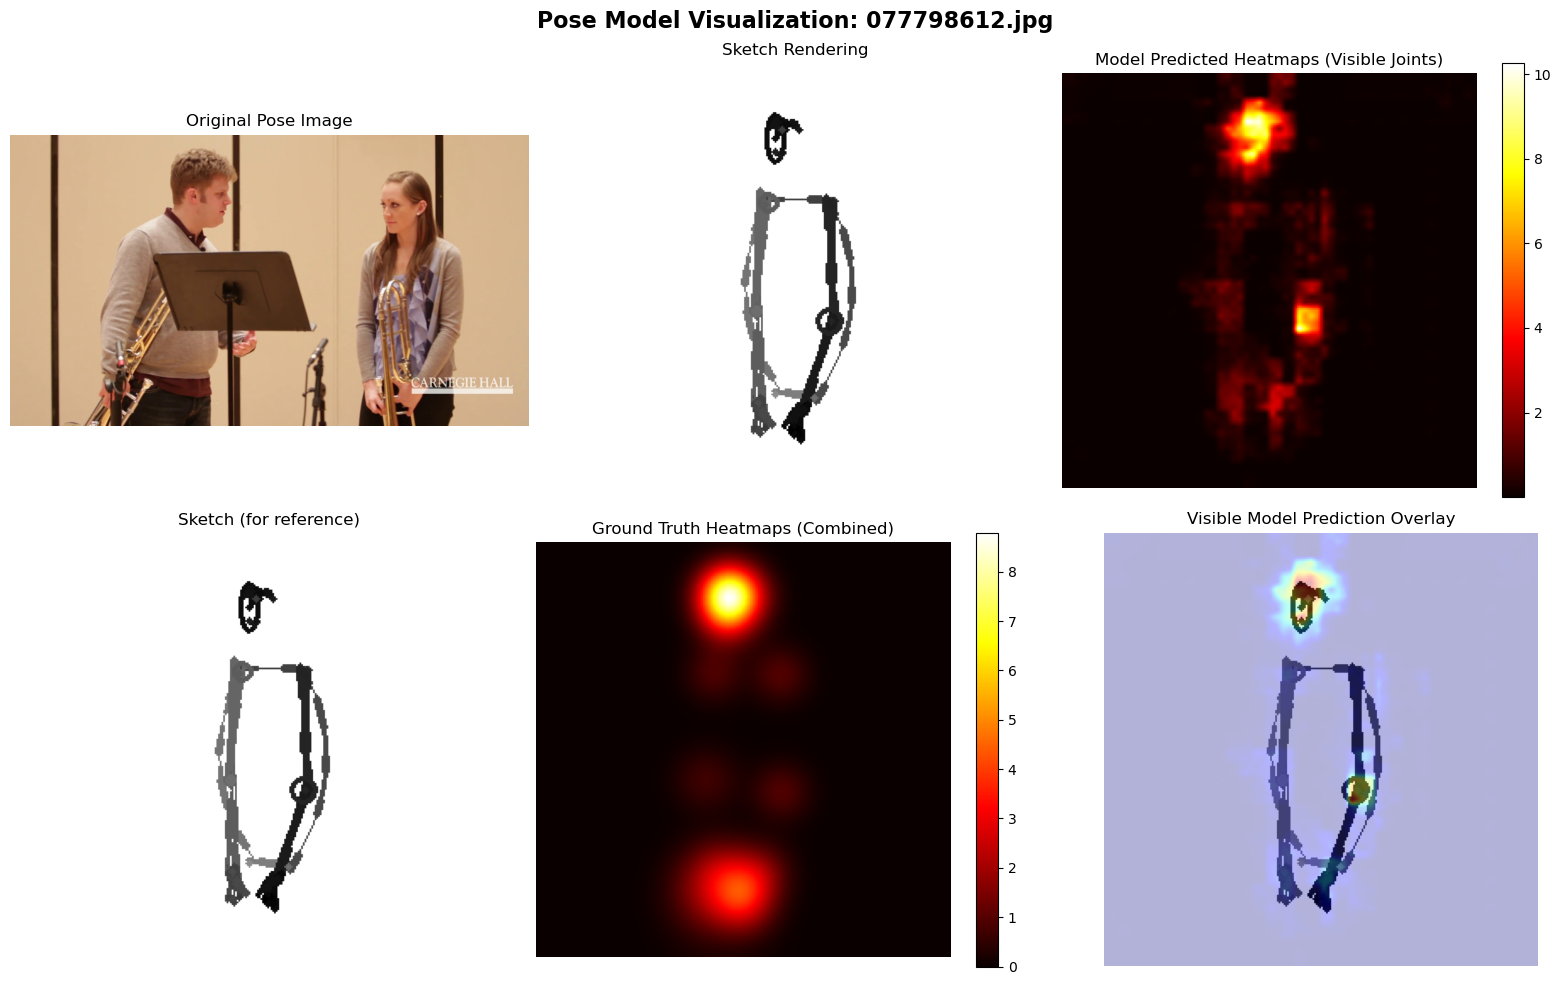

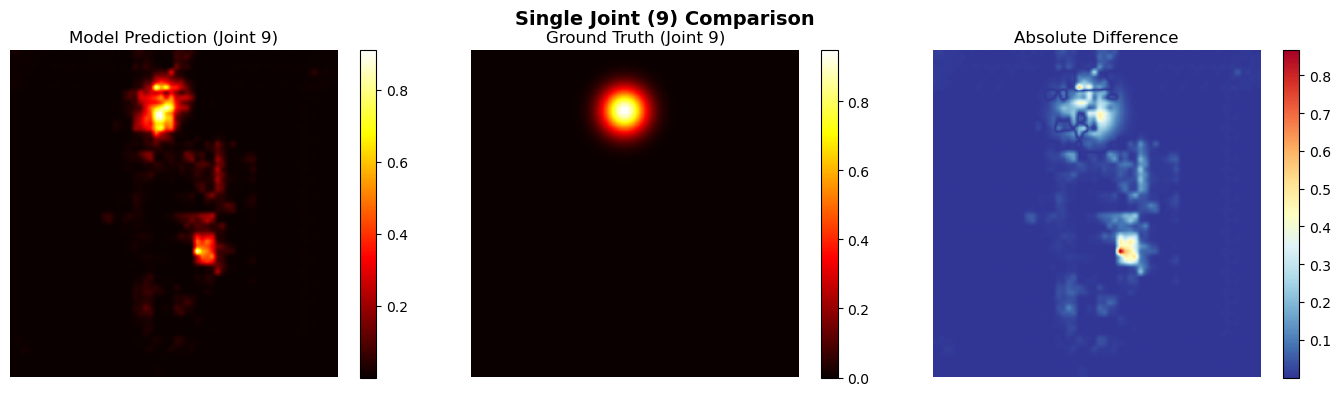


Visualization complete with visibility filtering.


In [36]:
import random
from pathlib import Path

# ============================================================
# 1. LOAD THE TRAINED MODEL
# ============================================================
model_save_path = f"{PATH}/../data/models/pose_model_added_visibility_epoch_80.pth"
loaded_model = load_model(model_save_path)
print(f"Model loaded from: {model_save_path}")

# ============================================================
# 2. PICK A RANDOM POSE PNG FROM THE DATASET
# ============================================================
image_dir = Path(f"{PATH}/mpii_human_pose_v1/images")
all_images = list(image_dir.glob("*.jpg"))
random_image_path = random.choice(all_images)
print(f"Selected random image: {random_image_path.name}")

# ============================================================
# 3. LOAD IMAGE AND DETECT POSE LANDMARKS
# ============================================================
try:
    random_image = mp.Image.create_from_file(str(random_image_path))
    random_detection_result = detector.detect(random_image)

    if not random_detection_result.pose_landmarks:
        print("No pose detected in this image, trying another...")
        for _ in range(5):
            random_image_path = random.choice(all_images)
            random_image = mp.Image.create_from_file(str(random_image_path))
            random_detection_result = detector.detect(random_image)
            if random_detection_result.pose_landmarks:
                print(f"Found pose in: {random_image_path.name}")
                break
except Exception as e:
    print(f"Error loading image: {e}")

# ============================================================
# 4. CREATE SKELETON AND SKETCH
# ============================================================
skeleton = construct_skeleton_from_mediapipe_result(
    random_detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.2,
)
stylized_skel = stylize_as_sketch(skeleton)
sketch_rgba = stylized_skel.render()  # RGBA (256, 256, 4)

# Blend onto white background for visibility
sketch_tensor = composite_sketch_on_white(sketch_rgba)  # RGB (256, 256, 3)

# ============================================================
# 5. GENERATE GROUND TRUTH HEATMAPS
# ============================================================
ground_truth_heatmaps, _ = construct_bounded_gaussian_from_landmarks(
    random_detection_result,
    edges
)
print(f"Ground truth heatmaps shape: {ground_truth_heatmaps.shape}")

# ============================================================
# 6. PREPARE SKETCH FOR MODEL INFERENCE
# ============================================================
# Resize sketch to 64x64 and normalize
sketch_for_model = cv2.resize(sketch_tensor, (64, 64), interpolation=cv2.INTER_AREA)
sketch_for_model = sketch_for_model.astype(np.float32) / 255.0
sketch_tensor_input = torch.tensor(sketch_for_model).permute(2, 0, 1).unsqueeze(0)  # Add batch dim
sketch_tensor_input = sketch_tensor_input.to(device)

# ============================================================
# 7. RUN MODEL INFERENCE (HEATMAPS + VISIBILITY)
# ============================================================
with torch.no_grad():
    model_output = loaded_model(sketch_tensor_input)

if isinstance(model_output, (tuple, list)) and len(model_output) == 2:
    predicted_heatmaps, predicted_visibility = model_output
else:
    predicted_heatmaps = model_output
    # Backward compatibility for older checkpoints without visibility head.
    predicted_visibility = torch.ones(
        (predicted_heatmaps.shape[0], predicted_heatmaps.shape[1]),
        dtype=predicted_heatmaps.dtype,
        device=predicted_heatmaps.device,
    )

predicted_heatmaps_np = predicted_heatmaps.squeeze(0).cpu().numpy()  # (33, 64, 64)
predicted_visibility_np = predicted_visibility.squeeze(0).cpu().numpy()  # (33,)

vis_threshold = 0.50
visible_joint_mask = predicted_visibility_np >= vis_threshold

# Keep at least one joint for visualization if all are below threshold.
if not np.any(visible_joint_mask):
    best_joint = int(np.argmax(predicted_visibility_np))
    visible_joint_mask[best_joint] = True

visible_predicted_heatmaps_np = predicted_heatmaps_np.copy()
visible_predicted_heatmaps_np[~visible_joint_mask] = 0.0

print(f"Predicted heatmaps shape: {predicted_heatmaps_np.shape}")
print(f"Visible joints from model: {int(np.sum(visible_joint_mask))}/33 (threshold={vis_threshold:.2f})")

# ============================================================
# 8. VISUALIZE RESULTS SIDE-BY-SIDE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"Pose Model Visualization: {random_image_path.name}", fontsize=16, fontweight='bold')

# Row 1: Original Image, Sketch, Predicted Heatmap
ax = axes[0, 0]
ax.imshow(random_image.numpy_view())
ax.set_title("Original Pose Image")
ax.axis('off')

ax = axes[0, 1]
ax.imshow(sketch_tensor.astype(np.uint8))
ax.set_title("Sketch Rendering")
ax.axis('off')

# Sum only visible predicted heatmaps for visualization
predicted_combined = np.sum(visible_predicted_heatmaps_np, axis=0)
predicted_resized = cv2.resize(predicted_combined, (256, 256))
ax = axes[0, 2]
im = ax.imshow(predicted_resized, cmap='hot')
ax.set_title("Model Predicted Heatmaps (Visible Joints)")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Row 2: Ground truth comparison
ax = axes[1, 0]
ax.imshow(sketch_tensor.astype(np.uint8))
ax.set_title("Sketch (for reference)")
ax.axis('off')

# Resize ground truth for overlay
ground_truth_combined = np.sum(ground_truth_heatmaps, axis=0)
gt_resized = cv2.resize(ground_truth_combined, (256, 256))
ax = axes[1, 1]
im = ax.imshow(gt_resized, cmap='hot')
ax.set_title("Ground Truth Heatmaps (Combined)")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Overlay visible predictions on sketch
ax = axes[1, 2]
sketch_rgb = sketch_tensor.astype(np.float32) / 255.0
denom = np.max(predicted_resized) + 1e-8
heatmap_color = plt.cm.jet(predicted_resized / denom)[:, :, :3]
overlay = 0.7 * sketch_rgb + 0.3 * heatmap_color
ax.imshow(overlay)
ax.set_title("Visible Model Prediction Overlay")
ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 9. DISPLAY SINGLE JOINT COMPARISON
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Choose the most visible predicted joint from the model output.
joint_idx = int(np.argmax(predicted_visibility_np))
fig.suptitle(f"Single Joint ({joint_idx}) Comparison", fontsize=14, fontweight='bold')

# Predicted heatmap for selected joint (masked if predicted invisible)
ax = axes[0]
predicted_joint = cv2.resize(visible_predicted_heatmaps_np[joint_idx], (256, 256))
im = ax.imshow(predicted_joint, cmap='hot')
ax.set_title(f"Model Prediction (Joint {joint_idx})")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Ground truth heatmap for selected joint
ax = axes[1]
gt_joint = cv2.resize(ground_truth_heatmaps[joint_idx], (256, 256))
im = ax.imshow(gt_joint, cmap='hot')
ax.set_title(f"Ground Truth (Joint {joint_idx})")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Difference
ax = axes[2]
diff = np.abs(predicted_joint - gt_joint)
im = ax.imshow(diff, cmap='RdYlBu_r')
ax.set_title("Absolute Difference")
ax.axis('off')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\nVisualization complete with visibility filtering.")

# Test on Random Sketch

In [37]:
import numpy as np

class Landmark:
    def __init__(self, x, y, z, visibility, presence=1.0, name=None):
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)
        self.visibility = float(visibility)
        self.presence = float(presence)
        self.name = name

    def __repr__(self):
        return f"Landmark(x={self.x}, y={self.y}, z={self.z}, visibility={self.visibility})"

In [38]:
def heatmaps_to_landmarks(heatmaps, temperature=0.1, topk_blend=0.3):
    """
    Improved soft-argmax with temperature scaling and top-k peak blending.
    
    Args:
        heatmaps:     (33, 64, 64) raw heatmap logits
        temperature:  lower = sharper (more argmax-like). 0.1 is a good default.
        topk_blend:   weight given to hard argmax of top-k region vs soft-argmax.
                      0.0 = pure soft-argmax, 1.0 = pure hard argmax of peak region.
    """
    num_joints, H, W = heatmaps.shape
    landmarks = []

    xs = np.linspace(0, 1, W)
    ys = np.linspace(0, 1, H)
    grid_x, grid_y = np.meshgrid(xs, ys)  # both (H, W)

    for i in range(num_joints):
        hm = heatmaps[i]  # (H, W)

        # --- Temperature-scaled softmax ---
        # Lower temperature makes this behave more like argmax (sharp peak → precise coord)
        # while still being differentiable/robust to noise
        scaled = hm / temperature
        hm_exp = np.exp(scaled - np.max(scaled))  # numerical stability
        prob = hm_exp / (np.sum(hm_exp) + 1e-8)

        # --- Soft-argmax coordinate ---
        x_soft = np.sum(prob * grid_x)
        y_soft = np.sum(prob * grid_y)

        # --- Hard argmax of local peak region (handles "concentrated but noisy" heatmaps) ---
        # Find the top-k% of the heatmap and take the centroid — more robust than single max pixel
        flat = hm.ravel()
        k = max(1, int(len(flat) * 0.02))  # top 2% of pixels
        topk_indices = np.argpartition(flat, -k)[-k:]
        topk_rows, topk_cols = np.unravel_index(topk_indices, (H, W))
        
        # Weight the top-k centroid by their heatmap values
        topk_vals = flat[topk_indices]
        topk_weights = topk_vals / (topk_vals.sum() + 1e-8)
        x_hard = np.sum(topk_weights * (topk_cols / (W - 1)))
        y_hard = np.sum(topk_weights * (topk_rows / (H - 1)))

        # --- Blend soft and hard estimates ---
        x = (1 - topk_blend) * x_soft + topk_blend * x_hard
        y = (1 - topk_blend) * y_soft + topk_blend * y_hard

        # --- Peak and spread metrics ---
        peak = np.max(hm)
        peak_mean_ratio = peak / (np.mean(hm) + 1e-8)  # how "spiky" is the heatmap

        # Variance computed around the BLENDED estimate (not just soft-argmax)
        var = np.sum(prob * ((grid_x - x)**2 + (grid_y - y)**2))

        # --- Improved visibility ---
        # Reward: high peak relative to mean (spiky = confident)
        # Penalize: high variance, but only when the peak isn't dominant
        # This handles "noisy but clearly peaked" heatmaps much better
        spikiness = np.clip(peak_mean_ratio / 20.0, 0, 1)   # normalize ~0-1
        spread_penalty = 1.0 / (1.0 + 8.0 * var)
        visibility = 0.6 * spikiness + 0.4 * spread_penalty
        visibility = float(np.clip(visibility, 0, 1))

        z = -peak

        landmarks.append(Landmark(x, y, z, visibility, name=str(i)))

    return landmarks

In [39]:
def create_sketch_from_image(filename):
    img = cv2.imread(f"{PATH}/{filename}")
    if img is None:
        raise ValueError(f"Could not read image: {PATH}/{filename}")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Stronger edges + thicker strokes for a more pronounced sketch
    edges = cv2.Canny(blurred, 35, 120)
    kernel = np.ones((3, 3), np.uint8)
    thick_edges = cv2.dilate(edges, kernel, iterations=2)

    sketch = 255 - thick_edges

    # 6. Normalize to [0.0, 1.0] as float32
    sketch_normalized = sketch.astype(np.float32) / 255.0

    return sketch_normalized

In [40]:
# End-to-end test: sketch -> model heatmaps -> landmarks -> labeled visualization
from pathlib import Path
import random
import torch

file = "IMG_1722.jpeg"

sketch_gray = create_sketch_from_image(file)  # (H, W), float in [0, 1]

sketch_64 = cv2.resize(sketch_gray, (64, 64), interpolation=cv2.INTER_AREA)
sketch_64_3ch = np.stack([sketch_64, sketch_64, sketch_64], axis=-1)
input_tensor = torch.tensor(sketch_64_3ch, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1414105..1.0000002].


input_tensor shape: (1, 3, 64, 64)
input_tensor dtype: torch.float32
input value range: 0.14141049981117249 to 1.000000238418579


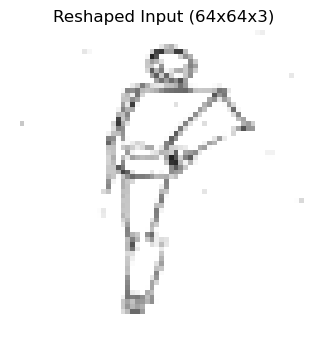

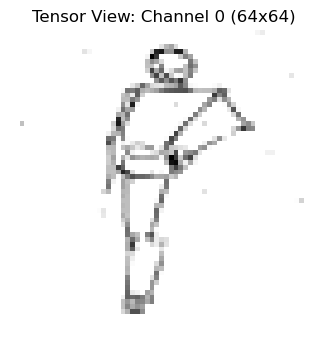

In [41]:
# Visualize the reshaped model input
print("input_tensor shape:", tuple(input_tensor.shape))  # expected: (1, 3, 64, 64)
print("input_tensor dtype:", input_tensor.dtype)
print("input value range:", float(input_tensor.min().item()), "to", float(input_tensor.max().item()))

# Show the exact 64x64x3 array used to build input_tensor
plt.figure(figsize=(4, 4))
plt.imshow(sketch_64_3ch)
plt.title("Reshaped Input (64x64x3)")
plt.axis("off")
plt.show()

# Show channel-0 directly from the tensor (should match grayscale sketch)
tensor_img = input_tensor[0].detach().cpu().permute(1, 2, 0).numpy()
plt.figure(figsize=(4, 4))
plt.imshow(tensor_img[:, :, 0], cmap="gray")
plt.title("Tensor View: Channel 0 (64x64)")
plt.axis("off")
plt.show()

In [84]:

# ============================================================
# 1. LOAD THE TRAINED MODEL
# ============================================================
model_save_path = f"{PATH}/../data/models/pose_model_added_visibility_epoch_40.pth"
loaded_model = load_model(model_save_path)
print(f"Model loaded from: {model_save_path}")

# ============================================================
# 2. PICK A RANDOM POSE PNG FROM THE DATASET
# ============================================================
image_dir = Path(f"{PATH}/mpii_human_pose_v1/images")
all_images = list(image_dir.glob("*.jpg"))
random_image_path = random.choice(all_images)
print(f"Selected random image: {random_image_path.name}")

# ============================================================
# 3. LOAD IMAGE AND DETECT POSE LANDMARKS
# ============================================================
try:
    random_image = mp.Image.create_from_file(str(random_image_path))
    random_detection_result = detector.detect(random_image)
    
    if not random_detection_result.pose_landmarks:
        print("No pose detected in this image, trying another...")
        for _ in range(5):
            random_image_path = random.choice(all_images)
            random_image = mp.Image.create_from_file(str(random_image_path))
            random_detection_result = detector.detect(random_image)
            if random_detection_result.pose_landmarks:
                print(f"Found pose in: {random_image_path.name}")
                break
except Exception as e:
    print(f"Error loading image: {e}")

# ============================================================
# 4. CREATE SKELETON AND SKETCH
# ============================================================
skeleton = construct_skeleton_from_mediapipe_result(
    random_detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.2,
)
stylized_skel = stylize_as_sketch(skeleton)
sketch_rgba = stylized_skel.render()  # RGBA (256, 256, 4)

# Blend onto white background for visibility
sketch_tensor = composite_sketch_on_white(sketch_rgba)  # RGB (256, 256, 3)

# ============================================================
# 5. GENERATE GROUND TRUTH HEATMAPS
# ============================================================
ground_truth_heatmaps, _ = construct_bounded_gaussian_from_landmarks(
    random_detection_result, 
    edges
)
print(f"Ground truth heatmaps shape: {ground_truth_heatmaps.shape}")

# ============================================================
# 6. PREPARE SKETCH FOR MODEL INFERENCE
# ============================================================
# Resize sketch to 64x64 and normalize
sketch_for_model = cv2.resize(sketch_tensor, (64, 64), interpolation=cv2.INTER_AREA)
sketch_for_model = sketch_for_model.astype(np.float32) / 255.0
sketch_tensor_input = torch.tensor(sketch_for_model).permute(2, 0, 1).unsqueeze(0)  # Add batch dim
sketch_tensor_input = sketch_tensor_input.to(device)


Model loaded from: C:/Users/leahz/Documents/ATC/pose-project/data/../data/models/pose_model_added_visibility_epoch_40.pth
Selected random image: 041776678.jpg
Ground truth heatmaps shape: (33, 64, 64)


Prepared input tensor shape: (1, 3, 64, 64)
Predicted heatmaps shape: (33, 64, 64)
Visible joints from model: 33/33 (threshold=0.50)


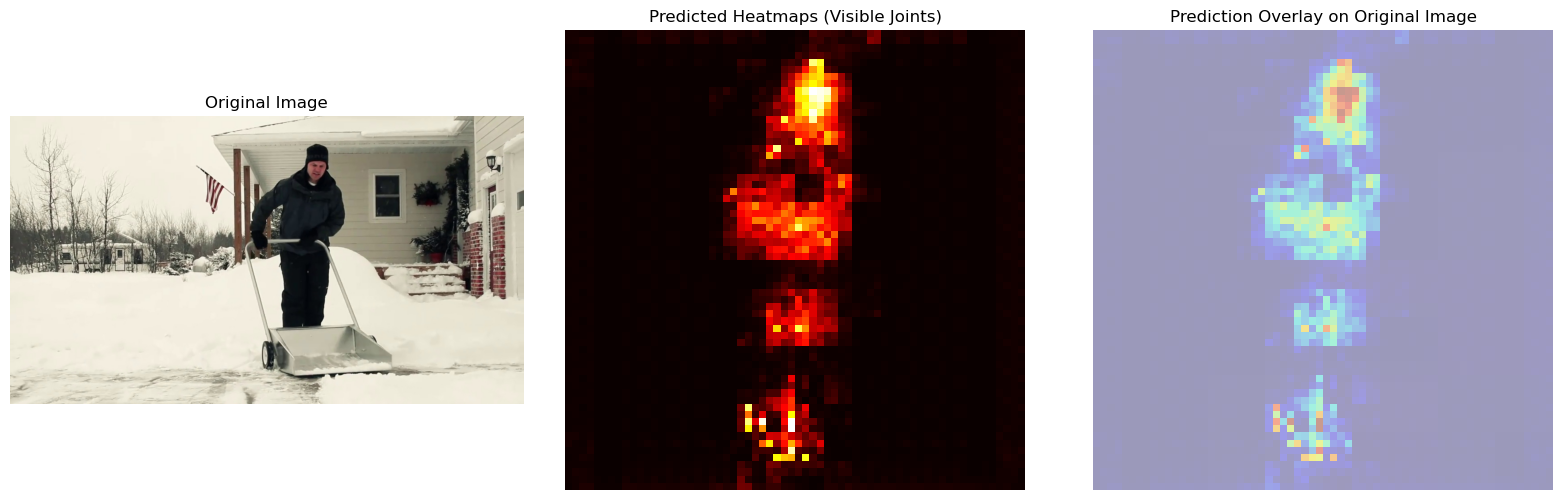

Showing 33/33 joints (visibility threshold=0.50)


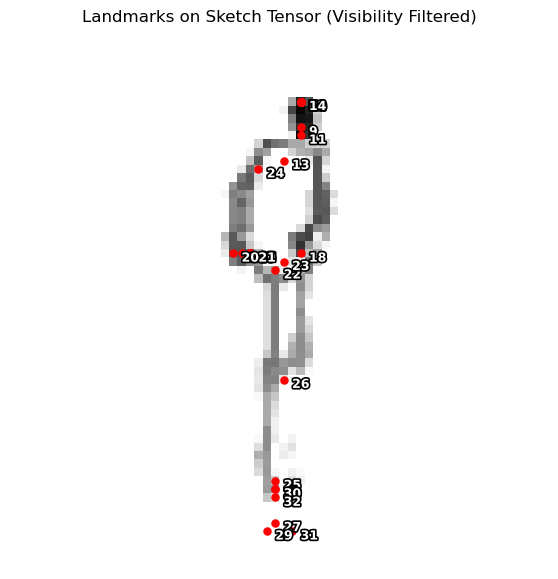

In [85]:
from matplotlib import patheffects as path_effects

# Use both the original image and the sketch tensor for display.
original_disp = random_image.numpy_view() if isinstance(random_image, mp.Image) else np.asarray(random_image)
if isinstance(sketch_tensor_input, torch.Tensor):
    sketch_disp = sketch_tensor_input[0].detach().cpu().permute(1, 2, 0).numpy()
else:
    sketch_disp = np.asarray(sketch_tensor_input)

# Run inference on the prepared sketch tensor.
if isinstance(sketch_tensor_input, torch.Tensor):
    tensor_img_t = sketch_tensor_input.float()
elif isinstance(tensor_img, np.ndarray):
    arr = tensor_img.astype(np.float32)
    if arr.ndim == 3:  # HWC -> NCHW
        arr = np.transpose(arr, (2, 0, 1))[None, ...]
    tensor_img_t = torch.from_numpy(arr).float()
else:
    tensor_img_t = torch.tensor(sketch_tensor_input, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

with torch.no_grad():
    model_output = loaded_model(tensor_img_t)

if isinstance(model_output, (tuple, list)) and len(model_output) == 2:
    pred_heatmaps, pred_visibility = model_output
else:
    pred_heatmaps = model_output
    pred_visibility = torch.ones(
        (pred_heatmaps.shape[0], pred_heatmaps.shape[1]),
        dtype=pred_heatmaps.dtype,
        device=pred_heatmaps.device,
    )

predicted_heatmaps_np = pred_heatmaps.squeeze(0).cpu().numpy()  # (33, 64, 64)
predicted_visibility_np = pred_visibility.squeeze(0).cpu().numpy()  # (33,)

vis_threshold = 0.50
visible_mask = predicted_visibility_np >= vis_threshold
if not np.any(visible_mask):
    visible_mask[int(np.argmax(predicted_visibility_np))] = True

print(f"Prepared input tensor shape: {tuple(tensor_img_t.shape)}")
print(f"Predicted heatmaps shape: {predicted_heatmaps_np.shape}")
print(f"Visible joints from model: {int(np.sum(visible_mask))}/33 (threshold={vis_threshold:.2f})")

# Visualize the original image + combined visible heatmap + overlay.
if np.any(visible_mask):
    combined_hm = np.max(predicted_heatmaps_np[visible_mask], axis=0)
else:
    combined_hm = np.zeros_like(predicted_heatmaps_np[0])
combined_hm_norm = (combined_hm - combined_hm.min()) / (combined_hm.max() - combined_hm.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(original_disp)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(combined_hm_norm, cmap="hot")
axes[1].set_title("Predicted Heatmaps (Visible Joints)")
axes[1].axis("off")

axes[2].imshow(original_disp)
axes[2].imshow(combined_hm_norm, cmap="jet", alpha=0.35)
axes[2].set_title("Prediction Overlay on Original Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Plot only visible joints (from visibility head) on the sketch.
heatmaps = predicted_heatmaps_np
H_hm, W_hm = heatmaps.shape[1], heatmaps.shape[2]
display_h, display_w = sketch_disp.shape[0], sketch_disp.shape[1]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(sketch_disp)
ax.set_title("Landmarks on Sketch Tensor (Visibility Filtered)")
ax.axis("off")

for i, hm in enumerate(heatmaps):
    if not visible_mask[i]:
        continue

    y_hm, x_hm = np.unravel_index(np.argmax(hm), hm.shape)

    # Map heatmap pixel center to display pixel center.
    x_px = int(np.clip(np.round((x_hm + 0.5) * display_w / W_hm - 0.5), 0, display_w - 1))
    y_px = int(np.clip(np.round((y_hm + 0.5) * display_h / H_hm - 0.5), 0, display_h - 1))

    ax.scatter(x_px, y_px, s=26, c="red")

    txt = ax.text(
        x_px + 1,
        y_px + 1,
        f"{i}",
        color="white",
        fontsize=9,
        fontweight="bold"
    )
    txt.set_path_effects([
        path_effects.Stroke(linewidth=2.4, foreground="black"),
        path_effects.Normal()
    ])

print(f"Showing {int(np.sum(visible_mask))}/33 joints (visibility threshold={vis_threshold:.2f})")
plt.show()

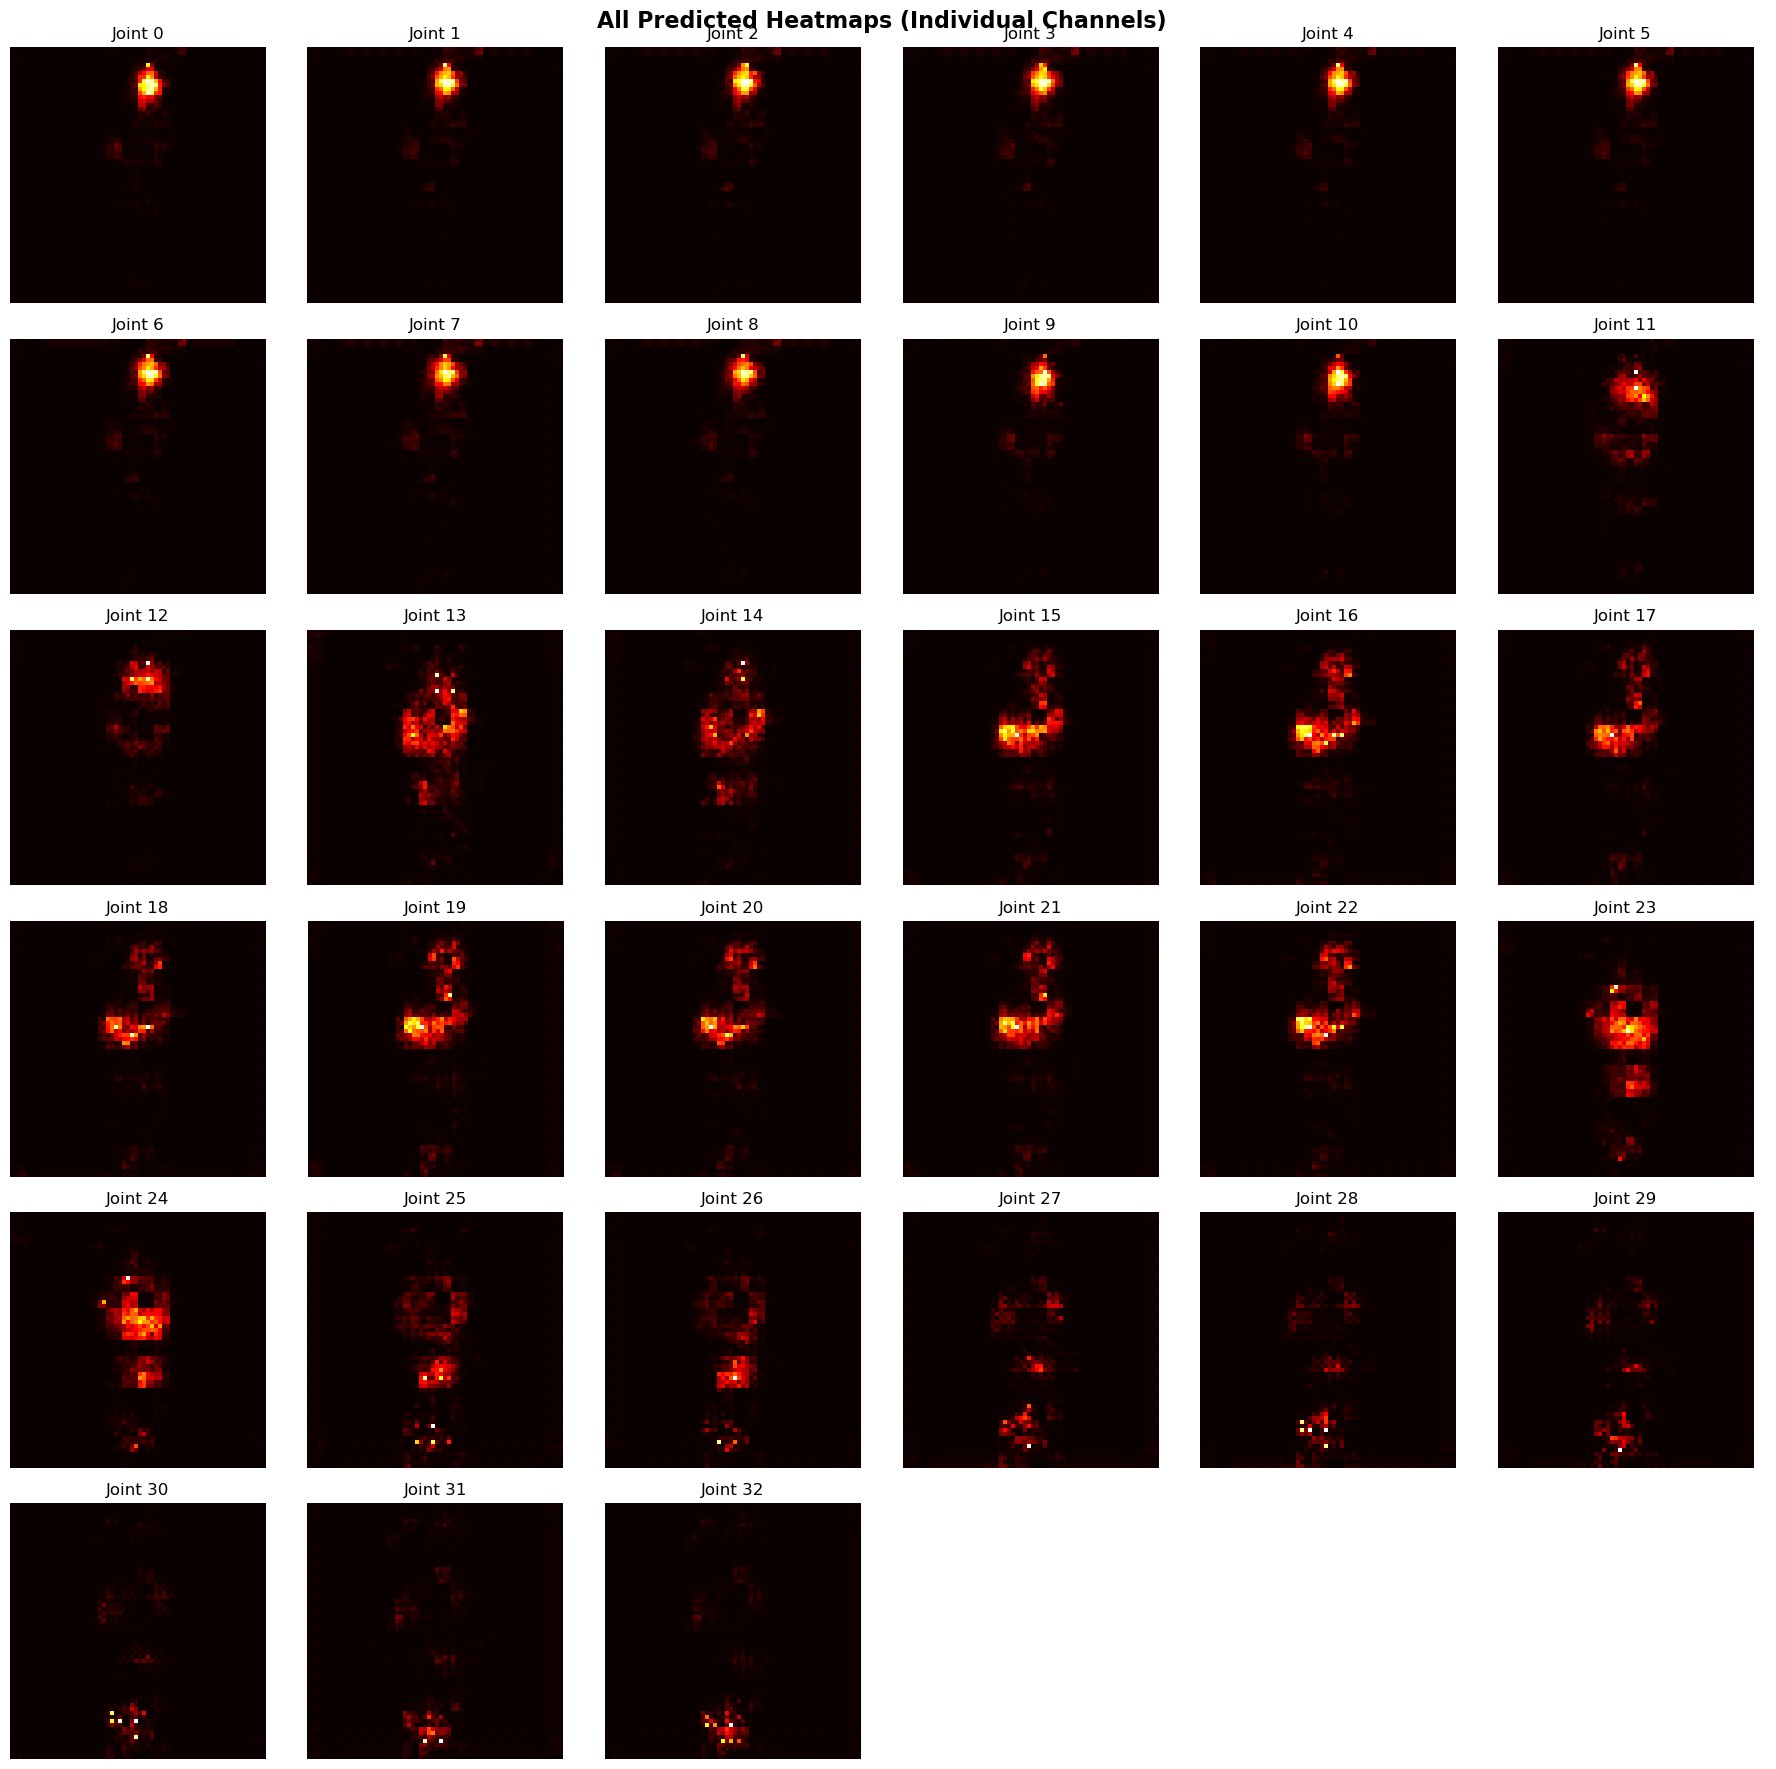

In [86]:
# Display all 33 heatmaps individually
if "predicted_heatmaps_np" not in globals():
    raise ValueError("No predicted heatmaps found. Run Cell 43 first.")

num_joints = predicted_heatmaps_np.shape[0]
if num_joints != 33:
    print(f"Note: expected 33 heatmaps, found {num_joints}")

cols = 6
rows = int(np.ceil(num_joints / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).reshape(rows, cols)

for idx in range(rows * cols):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    if idx < num_joints:
        hm = predicted_heatmaps_np[idx]
        im = ax.imshow(hm, cmap="hot")
        ax.set_title(f"Joint {idx}")
        ax.axis("off")
    else:
        ax.axis("off")

fig.suptitle("All Predicted Heatmaps (Individual Channels)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()